In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Conv2D

In [6]:
# Load the Fashion MNIST dataset split into training and testing sets
(train_x, train_y), (test_x, test_y) = fashion_mnist.load_data()

# 1. Expand dimensions from (28, 28) to (28, 28, 1) to satisfy the Conv2D layer input requirements
train_x = np.expand_dims(train_x, axis=-1)
test_x = np.expand_dims(test_x, axis=-1)

# 2. Convert data types to float32 and normalize pixel values to a range between [0, 1]
train_x = train_x.astype(np.float32) / 255.0
test_x = test_x.astype(np.float32) / 255.0

train_y = train_y.astype(np.float32)
test_y = test_y.astype(np.float32)

print("Training data shape:", train_x.shape)
print("Testing data shape:", test_x.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [7]:
model = Sequential()

# Add a Convolutional Layer to extract features (edges, textures) using 64 different filters
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)))

# Add a Max Pooling Layer to reduce the spatial size of the features, making processing faster
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten the multi-dimensional feature maps into a 1D vector
model.add(Flatten())

# Add a fully connected Hidden Layer with 128 neurons to learn abstract relationships
model.add(Dense(128, activation="relu"))

# Add the final Output Layer with 10 units (one per clothing class) using Softmax probabilities
model.add(Dense(10, activation="softmax"))

# Display the layout, shape transformations, and parameters of the neural network
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,384,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,386,506 (5.29 MB)

 Trainable params: 1,386,506 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
history = model.fit(train_x, train_y, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.8603 - loss: 0.3986 - val_accuracy: 0.8817 - val_loss: 0.3222
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9029 - loss: 0.2679 - val_accuracy: 0.8913 - val_loss: 0.2930
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.9187 - loss: 0.2207 - val_accuracy: 0.9081 - val_loss: 0.2574
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9299 - loss: 0.1845 - val_accuracy: 0.9162 - val_loss: 0.2376
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9429 - loss: 0.1549 - val_accuracy: 0.9092 - val_loss: 0.2637


In [10]:
  loss, acc = model.evaluate(test_x, test_y)
print(f"\nTest Evaluation Loss: {loss:.4f}")
print(f"Test Evaluation Accuracy: {acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9028 - loss: 0.2867

Test Evaluation Loss: 0.2867
Test Evaluation Accuracy: 90.28%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predicted Class: ankle_boots


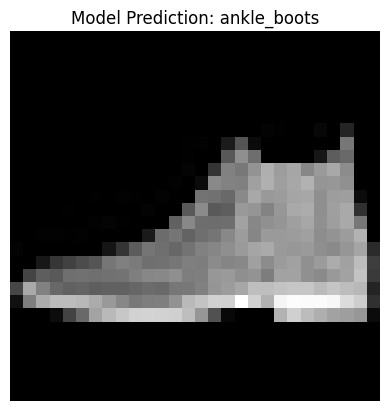

In [11]:
# Human-readable labels representing clothing item classes 0 through 9
labels = ['t_shirt', 'trouser', 'pullover', 'dress', 'coat', 'sandal', 'shirt', 'sneaker', 'bag', 'ankle_boots']

# Predict the class probabilities for the very first test image
predictions = model.predict(test_x[:1])

# Extract the index of the highest probability value
predicted_class_index = np.argmax(predictions)
label_prediction = labels[predicted_class_index]

print(f"Predicted Class: {label_prediction}")

# Remove the channel dimension with squeeze() so matplotlib can plot it as a 2D grayscale image
plt.imshow(test_x[0].squeeze(), cmap='gray')
plt.title(f"Model Prediction: {label_prediction}")
plt.axis('off')  # Hide grid axis lines
plt.show()       # Render the plot window correctly